# 머신러닝 분류

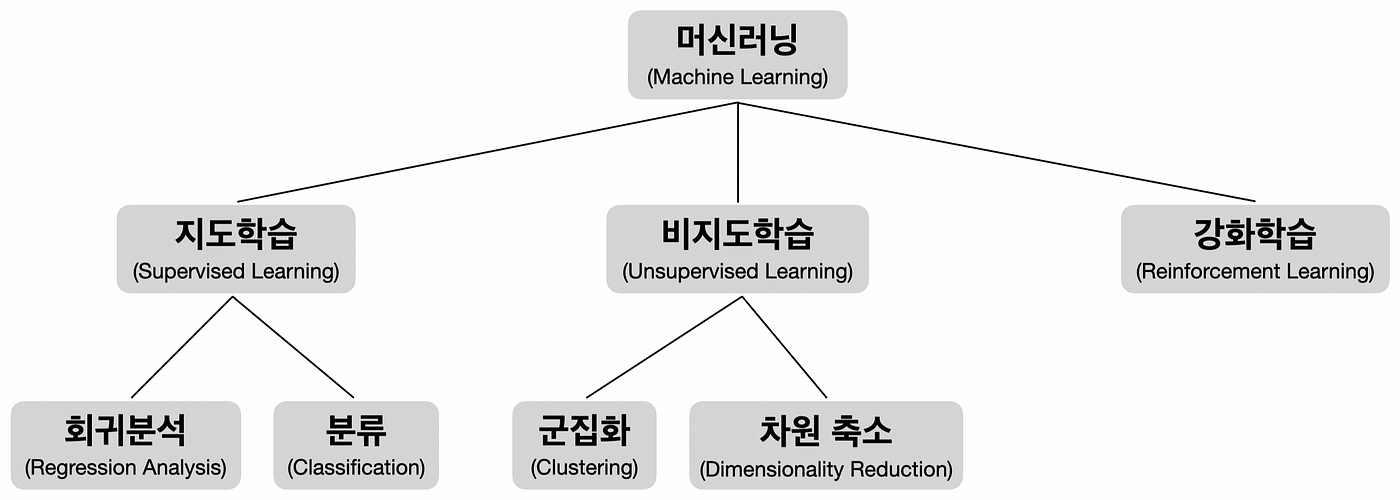

## k-NearestNeighbor(k-최근접이웃) 알고리즘

 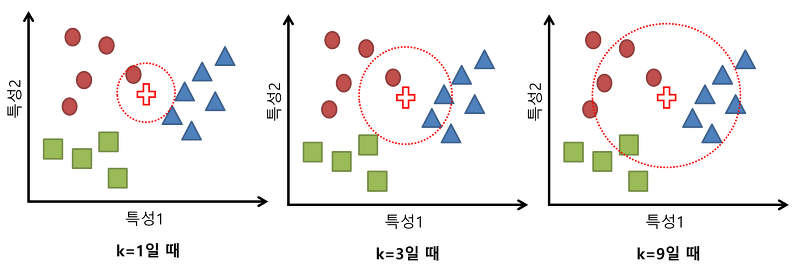

#붓꽃데이터 분류
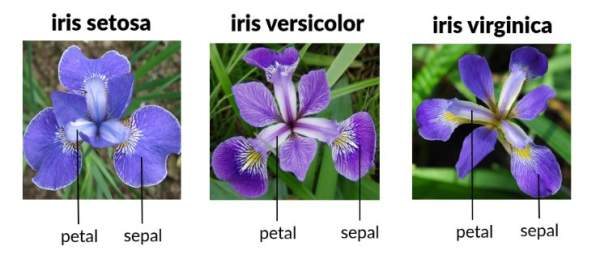

# 데이터 준비

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
iris = pd.read_csv('https://raw.githubusercontent.com/wizard113/ML-Basic/main/iris.csv')

In [ ]:
iris.head(5)

,caseno,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


In [ ]:
iris.head(10)

,caseno,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa
5,6,5.4,3.9,1.7,0.4,setosa
6,7,4.6,3.4,1.4,0.3,setosa
7,8,5.0,3.4,1.5,0.2,setosa
8,9,4.4,2.9,1.4,0.2,setosa
9,10,4.9,3.1,1.5,0.1,setosa


In [ ]:
iris.tail()

,caseno,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
145,146,6.7,3.0,5.2,2.3,virginica
146,147,6.3,2.5,5.0,1.9,virginica
147,148,6.5,3.0,5.2,2.0,virginica
148,149,6.2,3.4,5.4,2.3,virginica
149,150,5.9,3.0,5.1,1.8,virginica


In [ ]:
iris.describe()

,caseno,SepalLength,SepalWidth,PetalLength,PetalWidth
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.057333,3.758000,1.199333
std,43.445368,0.828066,0.435866,1.765298,0.762238
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [ ]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   caseno       150 non-null    int64  
 1   SepalLength  150 non-null    float64
 2   SepalWidth   150 non-null    float64
 3   PetalLength  150 non-null    float64
 4   PetalWidth   150 non-null    float64
 5   Species      150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
iris['Species']

,Species
0,setosa
1,setosa
2,setosa
3,setosa
4,setosa
...,...
145,virginica
146,virginica
147,virginica
148,virginica


In [ ]:
iris[['PetalLength','PetalWidth']]

,PetalLength,PetalWidth
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


In [ ]:
np.unique(iris['Species'], return_counts=True)

(array(['setosa', 'versicolor', 'virginica'], dtype=object),
 array([50, 50, 50]))

In [ ]:
iris.columns

Index(['caseno', 'SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth',
       'Species'],
      dtype='object')

In [ ]:
iris.values

In [ ]:
iris = iris[['PetalLength', 'PetalWidth', 'Species']]

In [ ]:
iris.head()

,PetalLength,PetalWidth,Species
0,1.4,0.2,setosa
1,1.4,0.2,setosa
2,1.3,0.2,setosa
3,1.5,0.2,setosa
4,1.4,0.2,setosa


In [ ]:
setosa = iris[iris.Species=='setosa']
versicolor = iris[iris.Species=='versicolor']
virginica = iris[iris.Species=='virginica']


In [ ]:
import matplotlib.pyplot as plt

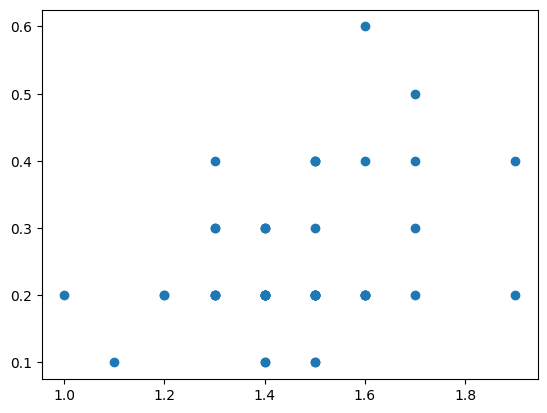

In [ ]:
plt.scatter(setosa['PetalLength'], setosa['PetalWidth'])

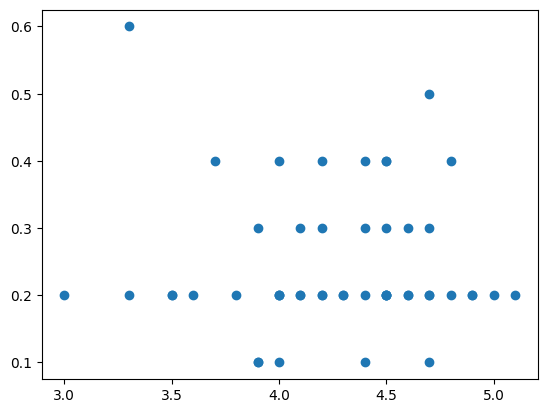

In [ ]:
plt.scatter(versicolor['PetalLength'], setosa['PetalWidth'])

In [ ]:
setosa = setosa.to_numpy()
versicolor = versicolor.to_numpy()
virginica = virginica.to_numpy()
print(setosa)

[[1.4 0.2 'setosa']
 [1.4 0.2 'setosa']
 [1.3 0.2 'setosa']
 [1.5 0.2 'setosa']
 [1.4 0.2 'setosa']
 [1.7 0.4 'setosa']
 [1.4 0.3 'setosa']
 [1.5 0.2 'setosa']
 [1.4 0.2 'setosa']
 [1.5 0.1 'setosa']
 [1.5 0.2 'setosa']
 [1.6 0.2 'setosa']
 [1.4 0.1 'setosa']
 [1.1 0.1 'setosa']
 [1.2 0.2 'setosa']
 [1.5 0.4 'setosa']
 [1.3 0.4 'setosa']
 [1.4 0.3 'setosa']
 [1.7 0.3 'setosa']
 [1.5 0.3 'setosa']
 [1.7 0.2 'setosa']
 [1.5 0.4 'setosa']
 [1.0 0.2 'setosa']
 [1.7 0.5 'setosa']
 [1.9 0.2 'setosa']
 [1.6 0.2 'setosa']
 [1.6 0.4 'setosa']
 [1.5 0.2 'setosa']
 [1.4 0.2 'setosa']
 [1.6 0.2 'setosa']
 [1.6 0.2 'setosa']
 [1.5 0.4 'setosa']
 [1.5 0.1 'setosa']
 [1.4 0.2 'setosa']
 [1.5 0.2 'setosa']
 [1.2 0.2 'setosa']
 [1.3 0.2 'setosa']
 [1.4 0.1 'setosa']
 [1.3 0.2 'setosa']
 [1.5 0.2 'setosa']
 [1.3 0.3 'setosa']
 [1.3 0.3 'setosa']
 [1.3 0.2 'setosa']
 [1.6 0.6 'setosa']
 [1.9 0.4 'setosa']
 [1.4 0.3 'setosa']
 [1.6 0.2 'setosa']
 [1.4 0.2 'setosa']
 [1.5 0.2 'setosa']
 [1.4 0.2 'setosa']]

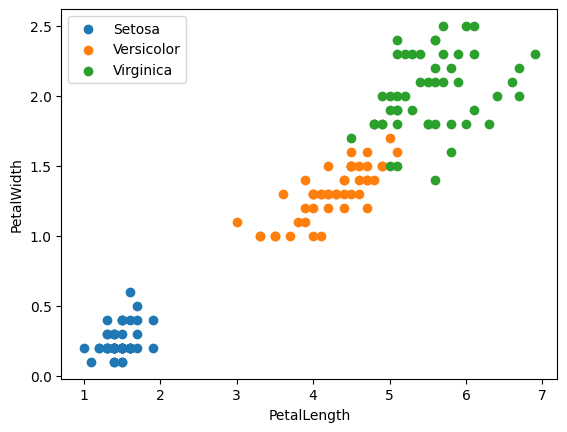

In [ ]:
plt.scatter(setosa[:, 0], setosa[:, 1])
plt.scatter(versicolor[:, 0], versicolor[:,1])
plt.scatter(virginica[:, 0], virginica[:,1])
plt.xlabel('PetalLength')
plt.ylabel('PetalWidth')
plt.legend(['Setosa', 'Versicolor', 'Virginica'])
plt.show()

## Data와 Target분리

In [ ]:
iris_input = iris[['PetalLength', 'PetalWidth']]
iris_target = iris['Species']

In [ ]:
print(iris_input.shape)
print(iris_target.shape)

(150, 2)
(150,)


## Dataframe을 Numpy ndarray로 변환

In [ ]:
iris_input = iris_input.to_numpy()
iris_target = iris_target.to_numpy()
print(iris_input)
print(iris_target)

[[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]
 [1.7 0.4]
 [1.4 0.3]
 [1.5 0.2]
 [1.4 0.2]
 [1.5 0.1]
 [1.5 0.2]
 [1.6 0.2]
 [1.4 0.1]
 [1.1 0.1]
 [1.2 0.2]
 [1.5 0.4]
 [1.3 0.4]
 [1.4 0.3]
 [1.7 0.3]
 [1.5 0.3]
 [1.7 0.2]
 [1.5 0.4]
 [1.  0.2]
 [1.7 0.5]
 [1.9 0.2]
 [1.6 0.2]
 [1.6 0.4]
 [1.5 0.2]
 [1.4 0.2]
 [1.6 0.2]
 [1.6 0.2]
 [1.5 0.4]
 [1.5 0.1]
 [1.4 0.2]
 [1.5 0.2]
 [1.2 0.2]
 [1.3 0.2]
 [1.4 0.1]
 [1.3 0.2]
 [1.5 0.2]
 [1.3 0.3]
 [1.3 0.3]
 [1.3 0.2]
 [1.6 0.6]
 [1.9 0.4]
 [1.4 0.3]
 [1.6 0.2]
 [1.4 0.2]
 [1.5 0.2]
 [1.4 0.2]
 [4.7 1.4]
 [4.5 1.5]
 [4.9 1.5]
 [4.  1.3]
 [4.6 1.5]
 [4.5 1.3]
 [4.7 1.6]
 [3.3 1. ]
 [4.6 1.3]
 [3.9 1.4]
 [3.5 1. ]
 [4.2 1.5]
 [4.  1. ]
 [4.7 1.4]
 [3.6 1.3]
 [4.4 1.4]
 [4.5 1.5]
 [4.1 1. ]
 [4.5 1.5]
 [3.9 1.1]
 [4.8 1.8]
 [4.  1.3]
 [4.9 1.5]
 [4.7 1.2]
 [4.3 1.3]
 [4.4 1.4]
 [4.8 1.4]
 [5.  1.7]
 [4.5 1.5]
 [3.5 1. ]
 [3.8 1.1]
 [3.7 1. ]
 [3.9 1.2]
 [5.1 1.6]
 [4.5 1.5]
 [4.5 1.6]
 [4.7 1.5]
 [4.4 1.3]
 [4.1 1.3]
 [4.  1.3]
 [4.4 1.2]

In [ ]:
iris_input.shape

(150, 2)

## Train, Test용 데이터분리

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_input, test_input, train_target, test_target \
= train_test_split(iris_input, iris_target, test_size=0.2, random_state=42)

In [ ]:
print(train_input.shape, train_target.shape)
print(test_input.shape, test_target.shape)

(120, 2) (120,)
(30, 2) (30,)


## 표준화

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [ ]:
train_scaled

# k-최근접 이웃 다중분류

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
kn = KNeighborsClassifier()
kn.fit(train_scaled, train_target)

KNeighborsClassifier()

In [ ]:
kn.score(test_scaled, test_target)

1.0

In [ ]:
kn = KNeighborsClassifier(3)
kn.fit(train_scaled, train_target)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
kn.score(test_scaled, test_target)

1.0

In [ ]:
k_nums = [1,3,5,7,9]
for k in k_nums:
  kn = KNeighborsClassifier(k)
  kn.fit(train_scaled, train_target)
  print('k={} : {}'.format(k, kn.score(test_scaled, test_target)))

k=1 : 1.0
k=3 : 1.0
k=5 : 1.0
k=7 : 1.0
k=9 : 1.0


In [ ]:
kn.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [ ]:
print(test_target[20:30])

['setosa' 'virginica' 'setosa' 'virginica' 'virginica' 'virginica'
 'virginica' 'virginica' 'setosa' 'setosa']


In [ ]:
kn.predict(test_scaled[20:30])

array(['setosa', 'virginica', 'setosa', 'virginica', 'virginica',
       'virginica', 'virginica', 'virginica', 'setosa', 'setosa'],
      dtype=object)

In [ ]:
kn.predict_proba(test_scaled[20:30])

array([[1.        , 0.        , 0.        ],
       [0.        , 0.22222222, 0.77777778],
       [1.        , 0.        , 0.        ],
       [0.        , 0.        , 1.        ],
       [0.        , 0.        , 1.        ],
       [0.        , 0.        , 1.        ],
       [0.        , 0.        , 1.        ],
       [0.        , 0.        , 1.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ]])

In [ ]:
[5.7, 2.3]